In [32]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import MinMaxScaler,FunctionTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import NotFittedError
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_auc_score

from sklearn.model_selection import RandomizedSearchCV

In [2]:
TRAIN_PATH = Path.cwd() / "train"
TEST_PATH = Path.cwd() / "test"

In [3]:
# Load Independent set  
X_train = pd.read_csv(TRAIN_PATH / "X_train.csv")
X_test = pd.read_csv(TEST_PATH / "X_test.csv")

# Load Dependent set
y_train = pd.read_csv(TRAIN_PATH / "y_train.csv").to_numpy().ravel()
y_test  = pd.read_csv(TEST_PATH  / "y_test.csv").to_numpy().ravel()

# Will later be updated by a try-catch block

In [4]:
X_train.select_dtypes(include="number").head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,credit_score
0,31.0,44485.0,4,8000.0,8.83,0.18,668
1,24.0,35851.0,0,8725.0,12.18,0.24,645
2,28.0,121251.0,6,25000.0,11.01,0.21,569
3,23.0,76537.0,1,12000.0,14.96,0.16,538
4,24.0,53633.0,4,23975.0,11.01,0.45,678


## Strategy for each column : 

#### 1. Pass-Through Features
* **`credit_score`**: Pass through without changes.

#### 2. Feature Engineering & Scaling
* **`person_emp_exp`** (Employment Experience):
    * **New Feature (`is_exp`)**: Indicator variable where `person_emp_exp == 0`.
    * **New Feature (`log_positive_exp`)**: Applies `np.log1p(x)` if `person_emp_exp > 0`, else `0`.
    * **Scaling**: Apply Min-Max Scaling to `log_positive_exp` values greater than 0.

#### 3. Binning & Discretisation
* **`person_age`**: Bin into four age groups:
    * `0–25`
    * `25–30`
    * `35–40`
    * `40+`
* **`loan_int_rate`**: Bin into two interest rate groups:
    * `< 11`
    * `> 11`

#### 4. Mathematical Transformations
* **`person_income`**: Apply `LogTransformer`.
* **`loan_amnt`**: Apply `SqrtTransformer`.
* **`loan_percent_income`**: Apply `SqrtTransformer`.


## Custom Classes and Transformers for Numeric Columns

In [5]:
# Creating custom class for person_age
class CustomBinner (BaseEstimator,TransformerMixin):
    """
    A custom class that slices the specified column into intervals passes by user as a list.
    """
    
    def __init__(self,intervals):
        """
        intervals : Pass on the interval range as list ; for example : 
            range : 0-10,10-20,20-30,>30
            Pass this range as [10,20,30] (Do not pass the upper and lower bounds of the bins)
            The first  and last interval will automatically take all the remaining values below it and above it respectively 
        dtype : list[int,float]
        """
        self.intervals = intervals

        # Whenever modifying data we store it into a new variable , also this new variable must be given a defensive level
        self._clean_intervals = sorted(list(intervals))

    
    def fit(self,X,y=None):
        """
        Validates the dataslice passed and it's structure.
        """

        # Check whether the user has actually passed intervals to fit or not
        if not self.intervals:
            raise ValueError(f"CustomBinner needs at least one split point. Got: {self.intervals!r}")
        # Check all the variables passed in the list are of type : int,float
        if not all(isinstance(v, (int, float)) for v in self.intervals):
            raise TypeError(f"All values in 'intervals' must be numeric. Got: {self.intervals!r}")

        # First check whether the data structure passed ( can be : pandas,polars,etc ) contains the column attribute or not.
        " A simple validation to segregate these datatypes from np.array ."

        if hasattr(X,"columns"):
            self.feature_names_in_ = np.array(X.columns,dtype=object)
            " Extract the columns from the passed data structure."
        else:
            " The other case is it is a numpy array where cols dont have names so we assign temp feature names."
            # Check how many dimensions the data structure has
            num_cols = X.shape[1] if len(X.shape) > 1 else 1
            self.feature_names_in_ = np.array([f"X_{i}" for i in range(num_cols)], dtype=object)


        return self # important

    def transform(self,X):
        """ 
        Applying the custom transformation on the data structure passed.
        """
        if not hasattr(self, "feature_names_in_"):
            raise NotFittedError("This CustomBinner instance is not fitted yet.")
        
        X_arr = np.asarray(X, dtype=float)
        
        # np.digitize automatically handles underflow (<10) and overflow (>=30) seamlessly!
        return np.digitize(X_arr, bins=self._clean_intervals)        
    
    def get_feature_names_out(self, input_features=None):
        """ 
        A method to fetch the feature names : Original if passed or temp.
        """
        if input_features is None: # If the feature names were not  
            return self.feature_names_in_
        return np.array(input_features, dtype=object) # Basically to maintain pipeline naming sense
    

# Defining separate custom interval maps
age_splits = [25, 35, 40]
rate_splits = [11]

In [6]:
# Creating custom class for person_emp_exp

# Branch A: The Indicator Flag (Outputs 1.0 if experience == 0, else 0.0)
indicator_branch = FunctionTransformer(
    lambda X: (X == 0).astype(float),
    feature_names_out=lambda self, input_features: [f"{f}_is_exp" for f in input_features]
)

# Branch B: The Log Scaler (Applies np.log1p math, then fits a MinMaxScaler)
log_scale_branch = Pipeline([
    ('log_math', FunctionTransformer(
        np.log1p, 
        feature_names_out=lambda self, input_features: [f"{f}_log_positive_exp" for f in input_features]
    )),
    ('scaler', MinMaxScaler())
])

# Traffic Controller: Combines both branches to run in parallel on the same column
experience_engineer = FeatureUnion([
    ('indicator_branch', indicator_branch),
    ('log_scale_branch', log_scale_branch)
])

In [7]:
# Columns to undergo log transformation : 
log_cols = ['person_income']

# Columns to undergo sqrt transformation :
sqrt_cols = ['loan_amnt','loan_percent_income']

# Columns to undergo min-max transformation :
minmax_cols_input = ['person_income', 'loan_amnt', 'loan_percent_income',
                     'credit_score', 'person_age', 'person_education']

## Custom Transformers and Strategy for Object Columns

In [8]:
# We will make a column transformer for the encoders and create a custom Mapper function for our custom mapping cols

In [9]:
X_train.select_dtypes(include="object").head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Associate,RENT,PERSONAL,Yes
1,female,Master,RENT,MEDICAL,Yes
2,female,High School,MORTGAGE,VENTURE,No
3,female,High School,RENT,MEDICAL,No
4,male,Associate,RENT,HOMEIMPROVEMENT,No


In [10]:
# To make sure the order for mapping cardinality values using OrdinalEncoder we will pass an explicit order to control behaviour
gender_order = ['female', 'male'] # Will map first value as 0 then next as 1 and so on...
file_order = ['No', 'Yes']

# Also the columns that we use OrdinalEncoder upon are : 
ord_cols = ["person_gender","previous_loan_defaults_on_file"]

# Now OneHotEncoded cols will be as decided : 
onc_cols = ["person_home_ownership","loan_intent"]

# Now handling our heirarchical col : person_education
heir_cols = ['person_education']

In [11]:
# Now creating a custom mapper for person_education
def home_ownership_mapper(X):

    hierarchy_map = {
                            'High School': 1,
                            'Associate': 2,
                            'Bachelor': 3,
                            'Master': 4,
                            'Doctorate' : 5
    }

    # 1. Convert to a NumPy array so the format is always consistent
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    
    # 2. Create a vectorized version of your dictionary lookup.
    # The .get(val, 0) handles missing values or typos by defaulting to 0.
    vector_lookup = np.vectorize(lambda val: hierarchy_map.get(val, 0))
    
    # 3. Apply it. This outputs the exact same 2D shape that came in.
    return vector_lookup(X)

# Wrap it up safely
home_ownership_transformer = FunctionTransformer(home_ownership_mapper, validate=False)

# Chaining Steps into a LogisticRegression PIPELINE 

In [12]:
# Column Transformer Sequential arranged 
col_transformer = ColumnTransformer(
        transformers = [
                            ('num_emp_features', experience_engineer, ['person_emp_exp']),

                            ('num_sqrt_transformer',
                                        Pipeline(
                                                  [
                                                        ('sqrt', FunctionTransformer(np.sqrt, validate=True)),
                                                        ('scaler', MinMaxScaler())
                                                   ]
                                                ),sqrt_cols),   # loan_amnt, loan_percent_income

                            ('num_log_transformer',
                                        Pipeline(
                                                  [
                                                        ('log', FunctionTransformer(np.log1p)),
                                                        ('scaler', MinMaxScaler())
                                                   ]
                                                ),log_cols),    # person_income

                            ('num_age_binner', CustomBinner(intervals=age_splits), ['person_age']),
                            ('num_rate_binner', CustomBinner(intervals=rate_splits), ['loan_int_rate']),
                            ("obj_enc_ord",OrdinalEncoder(
                                                                categories=[gender_order,file_order],
                                                                handle_unknown='use_encoded_value',
                                                                unknown_value=-1
                            ),ord_cols),
                            ("obj_enc_onc",OneHotEncoder(drop='first',handle_unknown='error'),onc_cols),
                            ("obj_enc_heir",home_ownership_transformer,heir_cols),
                            ('num_credit_score', MinMaxScaler(), ['credit_score']),
        ], 
        remainder='drop'
)

In [13]:
# Create the final pipeline for LogisticRegression
lor_pipeline = Pipeline(steps=[
    ('preprocessor', col_transformer),
    ('lor', LogisticRegression(max_iter=2000))
])

# Fit everything 
lor_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_emp_features', ...), ('num_sqrt_transformer', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

## Model Evaluation : LogisticRegression

In [14]:
# Make predictions and get probabilities 
y_pred       = lor_pipeline.predict(X_test)
y_pred_proba = lor_pipeline.predict_proba(X_test)[:, 1]  # Probability of class = 1 (Approved)

In [15]:
# Print the classification report and Plot the confusion matrix
print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

              precision    recall  f1-score   support

Rejected (0)       0.92      0.92      0.92      6999
Approved (1)       0.73      0.73      0.73      2000

    accuracy                           0.88      8999
   macro avg       0.83      0.83      0.83      8999
weighted avg       0.88      0.88      0.88      8999



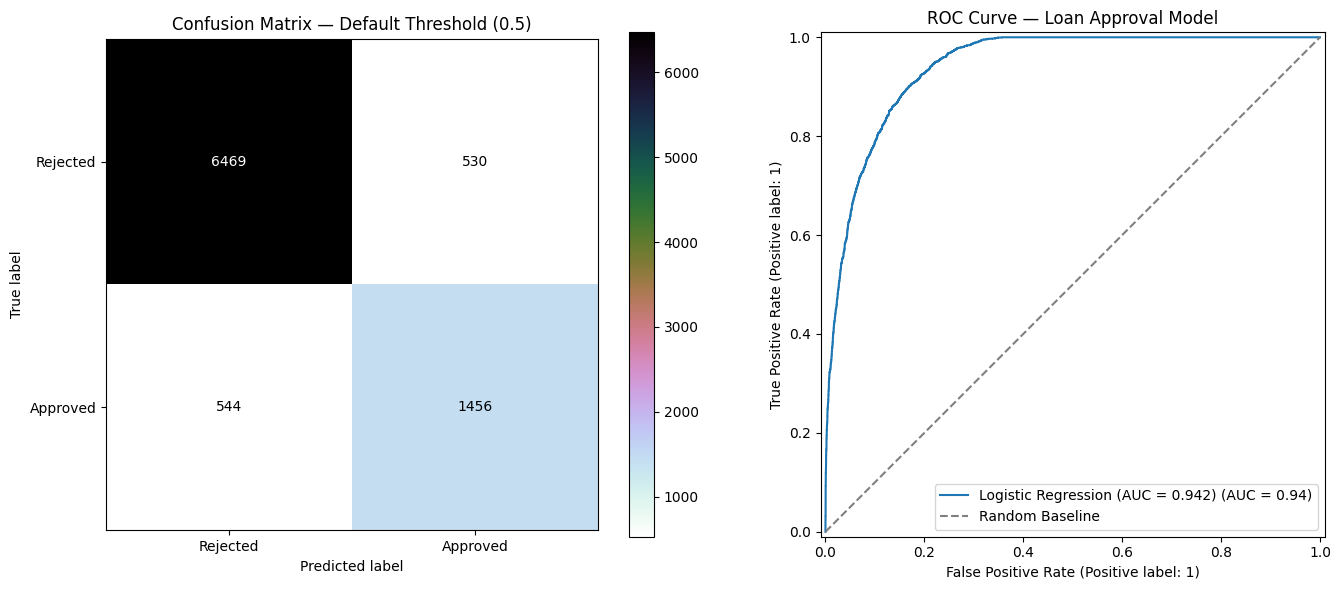

In [16]:
# Creates a side-by-side visualization comparing model classification accuracy and probability thresholds.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Plot: Confusion Matrix ---
# Displays the exact count of True Positives, True Negatives, False Positives, and False Negatives.
# Useful for identifying if the model misclassifies specific classes more often (e.g., high False Rejections).
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Rejected", "Approved"],
    cmap="cubehelix_r",
    ax=ax1  
)
ax1.set_title("Confusion Matrix — Default Threshold (0.5)", fontsize=12)

# --- Right Plot: ROC Curve ---
# Shows the trade-off between the True Positive Rate and False Positive Rate across all possible probability thresholds.
# The Area Under the Curve (AUC) measures the model's overall capability to distinguish between classes.
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})",
    ax=ax2  
)
# Draws the 50-50 random baseline; a model curve closer to the top-left corner indicates superior performance.
ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
ax2.set_title("ROC Curve — Loan Approval Model", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
# Our main aim was to reduce model from approving loans to people which are need to be rejected.
# In our case : we have 530 cases flagged to Approval but need to be rejected 

print(f'The percentage of FP cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred)[0,1]:.2f}%')
print(f'The percentage of FN cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred)[1,0]:.2f}%')

The percentage of FP cases : 16.98%
The percentage of FN cases : 16.54%


In [18]:
# The default threshold is 0.5. Raising it means the model must be more confident before saying "Approved", which reduces FPs.
thresholds = [ 0.60, 0.55, 0.50, 0.45, 0.40]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'FP Count':<10} {'FN Count'}")
print("-" * 70)

for t in thresholds:
    # Also remember that these are the probability for 1 that mean probability that a person will get loan.
    y_pred_t = (y_pred_proba >= t).astype(int) # Basically we are using custom thresholds to check the count for FP and FN accordingly.
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel() # Flatten and extract variables

    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score(y_test,   y_pred_t,  zero_division=0)
    f1 = f1_score(y_test,       y_pred_t,  zero_division=0)

    print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f1:<10.4f} {fp:<10} {fn}")

Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.7943       0.6235       0.6986     323        753
0.55         0.7673       0.6825       0.7224     414        635
0.50         0.7331       0.7280       0.7306     530        544
0.45         0.7038       0.7710       0.7359     649        458
0.40         0.6774       0.8095       0.7376     771        381


In [19]:
# TO be honest there is not much tuning we can do to linear models and we further experiment using RandomForestClassifier

# Chaining Steps into a RandomForestClassifier PIPELINE 

In [93]:
# Column Transformer Sequential arranged ~ For RandomForestClassifier especially
# Unlike LogisticRegression Tree model dont care about Distributions or Scale ; reducing workload.

col_transformer_rfc = ColumnTransformer(
        transformers = [
                            ('num_emp_features', experience_engineer, ['person_emp_exp']),
                            ('num_age_binner', CustomBinner(intervals=age_splits), ['person_age']),
                            ('num_rate_binner', CustomBinner(intervals=rate_splits), ['loan_int_rate']),
                            ("obj_enc_ord",OrdinalEncoder(
                                                                categories=[gender_order,file_order],
                                                                handle_unknown='use_encoded_value',
                                                                unknown_value=-1
                            ),ord_cols),
                            ("obj_enc_onc",OneHotEncoder(drop='first',handle_unknown='error'),onc_cols),
                            ("obj_enc_heir",home_ownership_transformer,heir_cols),
                            ('num_credit_score', MinMaxScaler(), ['credit_score']),
        ], 
        remainder='drop'
)

In [94]:
# Create another pipeline for RandomForestClassifier
rfc_pipeline = Pipeline(steps=[
    ('preprocessor', col_transformer_rfc),
    ('rfc', RandomForestClassifier(5))
])

# Fit everything 
rfc_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rfc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_emp_features', ...), ('num_age_binner', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of th

## Model Evaluation : RandomForestClassifier

In [95]:
# Make predictions and get probabilities 
y_pred_rfc       = rfc_pipeline.predict(X_test)
y_pred_proba_rfc = rfc_pipeline.predict_proba(X_test)[:, 1]  # Probability of class = 1 (Approved)

In [96]:
print(classification_report(y_test, y_pred_rfc, target_names=["Rejected (0)", "Approved (1)"]))

              precision    recall  f1-score   support

Rejected (0)       0.89      0.88      0.88      6999
Approved (1)       0.60      0.60      0.60      2000

    accuracy                           0.82      8999
   macro avg       0.74      0.74      0.74      8999
weighted avg       0.82      0.82      0.82      8999



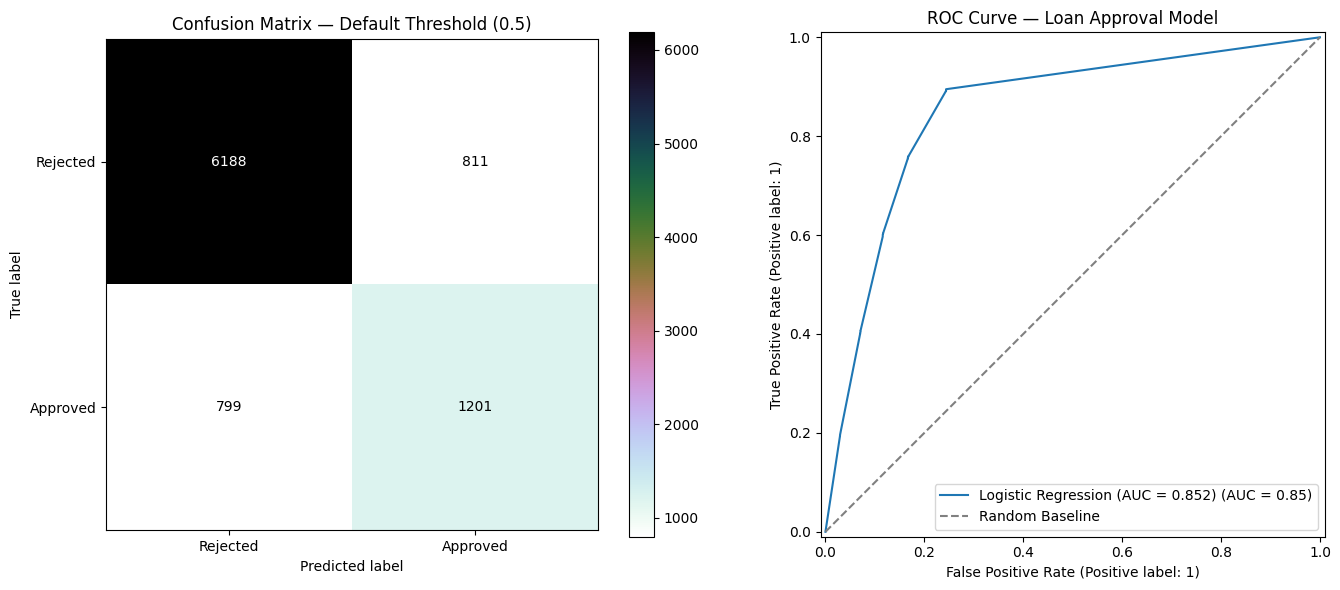

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Plot: Confusion Matrix ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rfc,
    display_labels=["Rejected", "Approved"],
    cmap="cubehelix_r",
    ax=ax1  
)
ax1.set_title("Confusion Matrix — Default Threshold (0.5)", fontsize=12)

# --- Right Plot: ROC Curve ---
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_rfc,
    name=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_rfc):.3f})",
    ax=ax2  
)
# Draws the 50-50 random baseline; a model curve closer to the top-left corner indicates superior performance.
ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
ax2.set_title("ROC Curve — Loan Approval Model", fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

In [98]:
print(f'The percentage of FP cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred_rfc)[0,1]:.2f}%')
print(f'The percentage of FN cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred_rfc)[1,0]:.2f}%')

The percentage of FP cases : 11.10%
The percentage of FN cases : 11.26%


In [99]:
# The default threshold is 0.5. Raising it means the model must be more confident before saying "Approved", which reduces FPs.
thresholds = [ 0.60, 0.55, 0.50, 0.45, 0.40]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'FP Count':<10} {'FN Count'}")
print("-" * 70)

for t in thresholds:
    # Also remember that these are the probability for 1 that mean probability that a person will get loan.
    y_pred_t = (y_pred_proba_rfc >= t).astype(int) # Basically we are using custom thresholds to check the count for FP and FN accordingly.
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel() # Flatten and extract variables

    p  = precision_score(y_test, y_pred_t, zero_division=0)
    r  = recall_score(y_test,   y_pred_t,  zero_division=0)
    f1 = f1_score(y_test,       y_pred_t,  zero_division=0)

    print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f1:<10.4f} {fp:<10} {fn}")

Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.5956       0.5965       0.5961     810        807
0.55         0.5958       0.5970       0.5964     810        806
0.50         0.5965       0.6025       0.5995     815        795
0.45         0.5965       0.6040       0.6002     817        792
0.40         0.5643       0.7550       0.6459     1166       490


In [28]:
# This model somewhat is still perforing worse than LogisticRegression Model , fine-tuning by RandomSearch is needed .

In [100]:
# We make a custom function to pass and test different model 
def eval_classification_model(model,model__params):
    import json
    # Print model params
    print(f'The model parameters:\n{json.dumps(model__params,indent=4,sort_keys=True)}')
    
    # Make predictions and get probabilities 
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class = 1 (Approved)
    print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left Plot: Confusion Matrix ---
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Rejected", "Approved"],
        cmap="cubehelix_r",
        ax=ax1  
    )
    ax1.set_title("Confusion Matrix — Default Threshold (0.5)", fontsize=12)

    # --- Right Plot: ROC Curve ---
    RocCurveDisplay.from_predictions(
        y_test,
        y_pred_proba,
        name=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})",
        ax=ax2  
    )
    # Draws the 50-50 random baseline; a model curve closer to the top-left corner indicates superior performance.
    ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Baseline')
    ax2.set_title("ROC Curve — Loan Approval Model", fontsize=12)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    print(f'The percentage of FP cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred)[0,1]:.2f}%')
    print(f'The percentage of FN cases : {y_test.shape[0]/confusion_matrix(y_test,y_pred)[1,0]:.2f}%')
    # The default threshold is 0.5. Raising it means the model must be more confident before saying "Approved", which reduces FPs.
    thresholds = [ 0.60, 0.55, 0.50, 0.45, 0.40]

    print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'FP Count':<10} {'FN Count'}")
    print("-" * 70)

    for t in thresholds:
        # Also remember that these are the probability for 1 that mean probability that a person will get loan.
        y_pred_t = (y_pred_proba >= t).astype(int) # Basically we are using custom thresholds to check the count for FP and FN accordingly.
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel() # Flatten and extract variables

        p  = precision_score(y_test, y_pred_t, zero_division=0)
        r  = recall_score(y_test,   y_pred_t,  zero_division=0)
        f1 = f1_score(y_test,       y_pred_t,  zero_division=0)

        print(f"{t:<12.2f} {p:<12.4f} {r:<12.4f} {f1:<10.4f} {fp:<10} {fn}")

### Hyper-parameter Tuning on RandomForestClassifier

In [29]:
# We will use the RandomSearch for this as I think it is the most effecient way to search

In [33]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Also make sure to add rfc__ at the start of each params as our model is fit inside a pipeline.
# Also ensure each params' values is inside a list when passed.

tree__params = {
                'rfc__class_weight': ['balanced'],
                'rfc__max_depth': [5],
                
                'rfc__n_jobs': [-1],
                'rfc__random_state': [46]

}

In [ ]:
random_search_rfr = RandomizedSearchCV(
                                            estimator=rfc_pipeline,
                                            param_distributions=tree__params,
                                            n_iter=10,
                                            cv=5,
                                            n_jobs=-1,
                                            random_state=46,
                                            scoring='precision'
)

In [107]:
random_search_rfr.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...timators=5))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rfc__class_weight': ['balanced'], 'rfc__max_depth': [5, 6, ...], 'rfc__n_jobs': [-1], 'rfc__random_state': [46]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",4
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchange

The model parameters:
{
    "rfc__class_weight": "balanced",
    "rfc__max_depth": null,
    "rfc__n_jobs": -1,
    "rfc__random_state": 46
}
              precision    recall  f1-score   support

Rejected (0)       0.89      0.89      0.89      6999
Approved (1)       0.60      0.60      0.60      2000

    accuracy                           0.82      8999
   macro avg       0.74      0.74      0.74      8999
weighted avg       0.82      0.82      0.82      8999



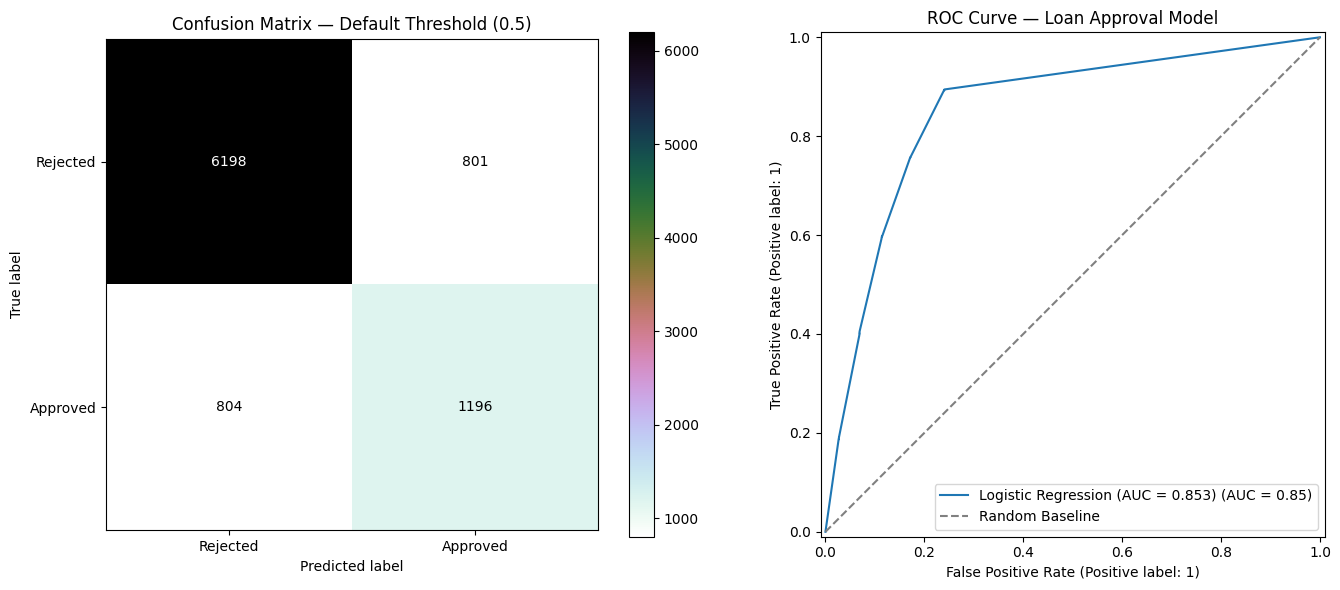

The percentage of FP cases : 11.23%
The percentage of FN cases : 11.19%
Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.5991       0.5925       0.5958     793        815
0.55         0.5991       0.5970       0.5980     799        806
0.50         0.5989       0.5980       0.5984     801        804
0.45         0.5989       0.5980       0.5984     801        804
0.40         0.5581       0.7560       0.6422     1197       488


In [108]:
eval_classification_model(random_search_rfr.best_estimator_,random_search_rfr.best_params_)

The model parameters:
{
    "rfc__bootstrap": true,
    "rfc__class_weight": "balanced",
    "rfc__criterion": "gini",
    "rfc__max_depth": 6,
    "rfc__min_samples_leaf": 2,
    "rfc__n_estimators": 100,
    "rfc__n_jobs": -1,
    "rfc__random_state": 46
}
              precision    recall  f1-score   support

Rejected (0)       0.98      0.77      0.86      6999
Approved (1)       0.53      0.93      0.68      2000

    accuracy                           0.80      8999
   macro avg       0.75      0.85      0.77      8999
weighted avg       0.88      0.80      0.82      8999



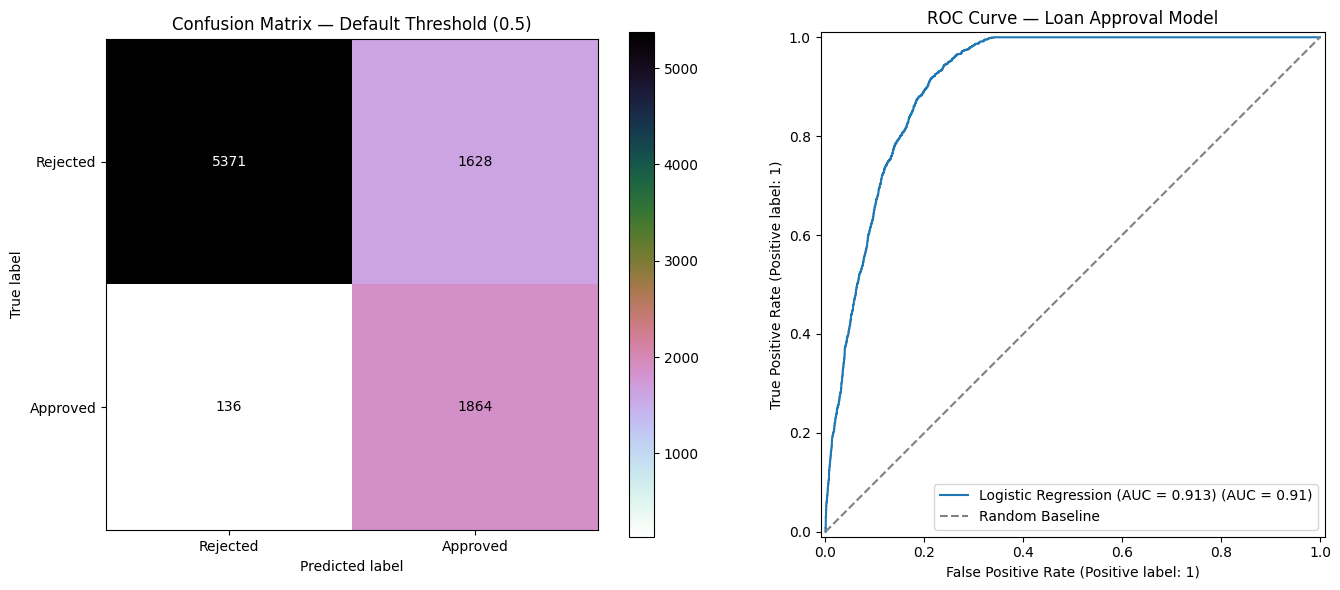

The percentage of FP cases : 5.53%
The percentage of FN cases : 66.17%
Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.5622       0.8875       0.6884     1382       225
0.55         0.5503       0.9160       0.6876     1497       168
0.50         0.5338       0.9320       0.6788     1628       136
0.45         0.5162       0.9540       0.6699     1788       92
0.40         0.4945       0.9745       0.6561     1992       51


In [104]:
eval_classification_model(random_search_rfr.best_estimator_,random_search_rfr.best_params_)

The model parameters:
{
    "rfc__class_weight": "balanced",
    "rfc__criterion": "gini",
    "rfc__max_depth": 6,
    "rfc__max_features": "log2",
    "rfc__n_estimators": 100,
    "rfc__n_jobs": -1,
    "rfc__random_state": 46
}
              precision    recall  f1-score   support

Rejected (0)       0.98      0.77      0.86      6999
Approved (1)       0.53      0.93      0.68      2000

    accuracy                           0.80      8999
   macro avg       0.75      0.85      0.77      8999
weighted avg       0.88      0.80      0.82      8999



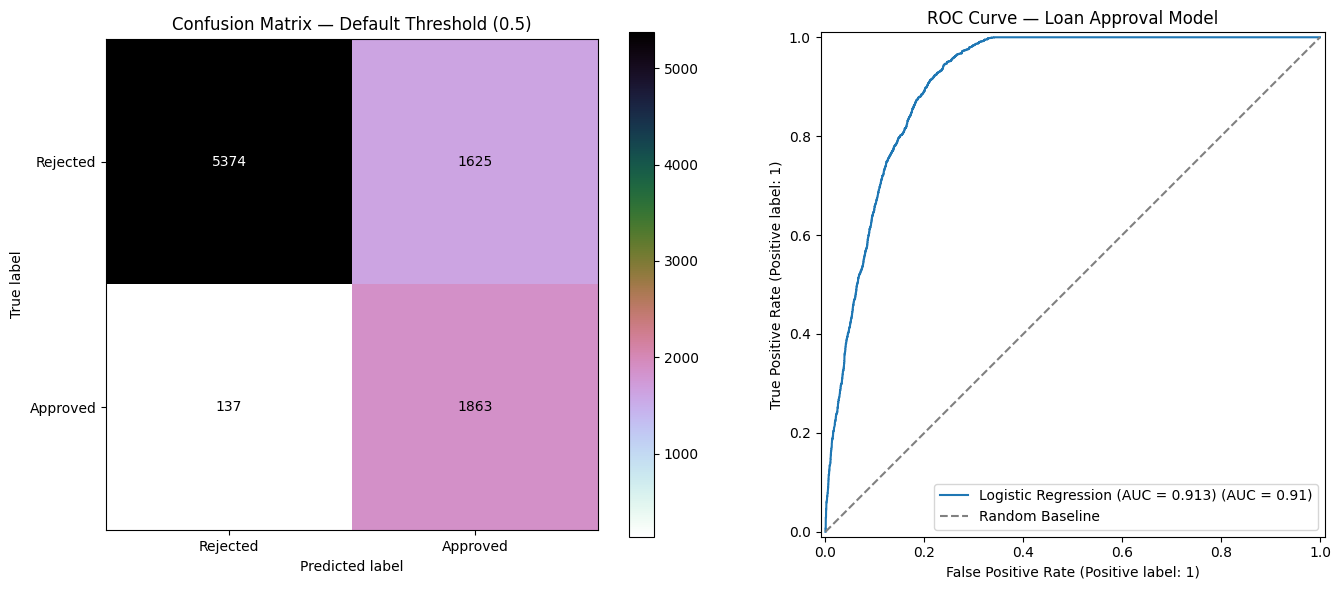

The percentage of FP cases : 5.54%
The percentage of FN cases : 65.69%
Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.5613       0.8885       0.6880     1389       223
0.55         0.5492       0.9150       0.6864     1502       170
0.50         0.5341       0.9315       0.6789     1625       137
0.45         0.5171       0.9545       0.6708     1783       91
0.40         0.4944       0.9750       0.6561     1994       50


In [66]:
eval_classification_model(random_search_rfr.best_estimator_,random_search_rfr.best_params_)

The model parameters:
{
    "rfc__class_weight": "balanced",
    "rfc__criterion": "gini",
    "rfc__max_depth": 6,
    "rfc__max_features": "sqrt",
    "rfc__n_estimators": 100,
    "rfc__n_jobs": -1,
    "rfc__random_state": 46
}
              precision    recall  f1-score   support

Rejected (0)       0.98      0.77      0.86      6999
Approved (1)       0.53      0.93      0.68      2000

    accuracy                           0.80      8999
   macro avg       0.75      0.85      0.77      8999
weighted avg       0.88      0.80      0.82      8999



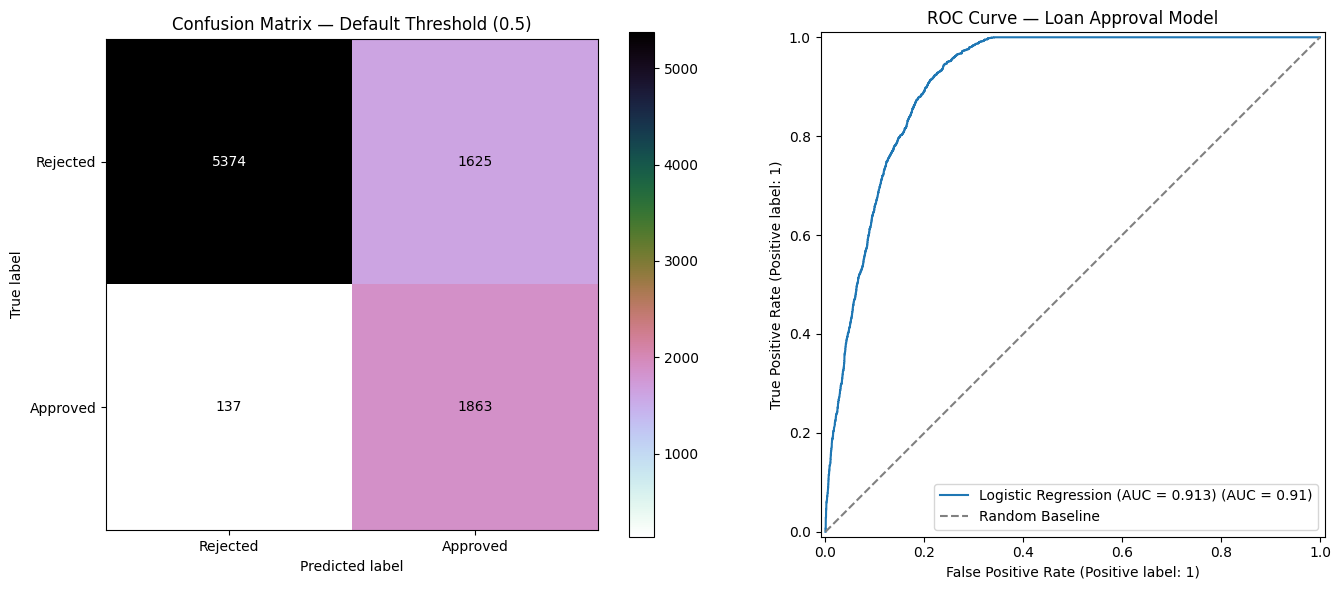

The percentage of FP cases : 5.54%
The percentage of FN cases : 65.69%
Threshold    Precision    Recall       F1         FP Count   FN Count
----------------------------------------------------------------------
0.60         0.5613       0.8885       0.6880     1389       223
0.55         0.5492       0.9150       0.6864     1502       170
0.50         0.5341       0.9315       0.6789     1625       137
0.45         0.5171       0.9545       0.6708     1783       91
0.40         0.4944       0.9750       0.6561     1994       50


In [59]:
eval_classification_model(random_search_rfr.best_estimator_,random_search_rfr.best_params_)